# Quantification du Risque de Longévité
## Combien faut-il provisionner pour un portefeuille de rentes ?

**Problème résolu :** Un assureur vie constitue un portefeuille de rentes viagères.
Si la mortalité s'améliore plus vite que prévu, il doit payer des rentes plus longtemps.
Ce notebook quantifie ce risque et calcule la provision réglementaire recommandée.

**Méthodologie :**
1. Portefeuille synthétique réaliste (100 contrats H+F)
2. Valorisation centrale par 4 modèles
3. Distribution des pertes par bootstrap (1000 simulations)
4. Provision P95 et P99 (standards Solvabilité II)
5. Stress tests réglementaires
6. Recommandation chiffrée

## 0. Setup

In [2]:
import os, sys

# Chemin absolu vers la racine du projet
PROJECT_ROOT = r"C:\Users\PC-HP\Desktop\insea\Mortality Project"
# ex : r"C:\Users\PC-HP\Downloads\pfa_insea"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Root : {PROJECT_ROOT}")
print(f"src trouvé : {os.path.exists(os.path.join(PROJECT_ROOT, 'src'))}")

Root : C:\Users\PC-HP\Desktop\insea\Mortality Project
src trouvé : True


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pmdarima as pm
from scipy import stats
 
from src.models.lee_carter       import fit_lee_carter
from src.models.life_expectancy  import compute_life_table
from src.models.cbd_model        import fit_cbd
from src.models.renshaw_haberman import fit_renshaw_haberman, get_gamma
from src.models.pricing          import compute_annuity

os.makedirs('outputs', exist_ok=True)
np.random.seed(42)

TAUX_TECH  = 0.02   # taux technique réglementaire
PROJ_YEAR  = 2025   # année de projection
HORIZON    = 40     # horizon rente (jusqu'à 105 ans)

def load_data():
    base = os.path.join(PROJECT_ROOT, 'data')
    df_d = pd.read_csv(os.path.join(base, 'france_deaths_clean.csv'))
    df_p = pd.read_csv(os.path.join(base, 'france_population_clean.csv'))
    d_l  = df_d.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Deaths')
    p_l  = df_p.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Population')
    df   = pd.merge(d_l, p_l, on=['Year','Age','Sex'])
    df['mx'] = df['Deaths'] / df['Population']
    return df[(df['Year'] >= 1950) & (df['Age'] <= 90) & (df['mx'] > 0)].copy()

df_all = load_data()
print('Setup OK')

Setup OK


## 1. Calibration des modèles sur 1950–2000
*(si déjà calibrés dans une autre session, cette cellule refit rapidement)*

In [4]:
models_params = {}

for sex in ['Female', 'Male']:
    df_tr = df_all[(df_all['Year']<=2000)&(df_all['Sex']==sex)].copy()
    ax, bx, kt = fit_lee_carter(df_tr)
    k1, k2, xbar = fit_cbd(df_tr, age_min=50, age_max=85)
    rh = fit_renshaw_haberman(df_tr)

    # CBD residual
    df_c = df_tr[(df_tr['Age']>=50)&(df_tr['Age']<=85)].copy()
    df_c['qx'] = (df_c['mx']/(1+0.5*df_c['mx'])).clip(1e-6,1-1e-6)
    df_c['lq'] = np.log(df_c['qx']/(1-df_c['qx']))
    piv  = df_c.pivot(index='Age',columns='Year',values='lq')
    ages_c = piv.index.values.astype(float)
    lfit = pd.DataFrame({y:k1[y]+k2[y]*(ages_c-xbar) for y in k1.index},index=ages_c)
    cbd_res = float(np.std((lfit.values-piv.values).ravel()))

    # LC residual
    piv_lc   = df_tr.pivot(index='Age',columns='Year',values='mx')
    log_obs  = np.log(piv_lc.clip(lower=1e-10).values)
    log_fit  = np.column_stack([ax.values+bx.values*kt[y] for y in kt.index])
    lc_res   = float(np.std((log_fit-log_obs).ravel()))

    models_params[sex] = {
        'ax':ax,'bx':bx,'kt':kt,
        'k1':k1,'k2':k2,'xbar':xbar,'ages_cbd':ages_c,'cbd_res':cbd_res,
        'rh':rh,'lc_res':lc_res
    }
    print(f'{sex:8s} — LC res={lc_res:.4f} | CBD res={cbd_res:.4f} | '
          f'RH res={rh["residual_std"]:.4f}')

Female   — LC res=0.0975 | CBD res=0.1342 | RH res=0.0748
Male     — LC res=0.0980 | CBD res=0.0832 | RH res=0.0727


## 2. Projection 2025 — tables de mortalité par modèle

In [5]:
def project_table(sex, model, params, proj_year=2025):
    """
    Construit la table de mortalité projetée pour une année cible.
    Retourne DataFrame Age/mx.
    """
    p  = params[sex]
    ax = p['ax']; bx = p['bx']; kt = p['kt']
    n_fc = proj_year - int(kt.index[-1])

    m_kt = pm.auto_arima(kt.values, seasonal=False, stepwise=True,
                          suppress_warnings=True, error_action='ignore')
    kt_25 = float(m_kt.predict(n_periods=n_fc)[-1])

    if model == 'Lee-Carter':
        mx = np.exp(ax.values + bx.values * kt_25).clip(min=1e-10)
        return pd.DataFrame({'Age': ax.index.tolist(), 'mx': mx})

    elif model == 'CBD':
        k1=p['k1']; k2=p['k2']; xbar=p['xbar']; ages_c=p['ages_cbd']
        m1 = pm.auto_arima(k1.values,seasonal=False,stepwise=True,
                            suppress_warnings=True,error_action='ignore')
        m2 = pm.auto_arima(k2.values,seasonal=False,stepwise=True,
                            suppress_warnings=True,error_action='ignore')
        k1_25 = float(m1.predict(n_periods=n_fc)[-1])
        k2_25 = float(m2.predict(n_periods=n_fc)[-1])
        lq    = k1_25 + k2_25*(ages_c-xbar)
        qx_c  = (np.exp(lq)/(1+np.exp(lq))).clip(1e-6,1-1e-6)
        mx_c  = (qx_c/(1-0.5*qx_c)).clip(min=1e-10)
        df_base = project_table(sex,'Lee-Carter',params,proj_year)
        df_cbd  = df_base.copy()
        for i,age in enumerate(ages_c.astype(int)):
            df_cbd.loc[df_cbd['Age']==age,'mx'] = mx_c[i]
        return df_cbd

    elif model == 'Renshaw-Haberman':
        rh = p['rh']
        ax_rh=rh['ax']; bx_rh=rh['bx']; ages_rh=rh['ages_arr']
        gamma_c=rh['gamma_c']
        gamma_s=pd.Series(gamma_c).sort_index()
        log_pred = np.array([
            ax_rh[ai]+bx_rh[ai]*kt_25+
            get_gamma(proj_year-ages_rh[ai],gamma_c,gamma_s)
            for ai in range(len(ages_rh))
        ])
        return pd.DataFrame({'Age':ages_rh.astype(int),
                              'mx':np.exp(log_pred).clip(min=1e-10)})

# Projeter toutes les tables
MODELS = ['Lee-Carter','CBD','Renshaw-Haberman']
tables = {sex: {m: project_table(sex,m,models_params) for m in MODELS}
          for sex in ['Female','Male']}

# Vérification e0 projeté
print('=== e0 projeté 2025 par modèle ===')
print(f'{"Modèle":22s} {"Femmes":>10s} {"Hommes":>10s}')
print('─'*44)
for m in MODELS:
    e0_f = compute_life_table(tables['Female'][m]).iloc[0]['ex']
    e0_m = compute_life_table(tables['Male'][m]).iloc[0]['ex']
    print(f'{m:22s} {e0_f:>10.3f} {e0_m:>10.3f}')

=== e0 projeté 2025 par modèle ===
Modèle                     Femmes     Hommes
────────────────────────────────────────────
Lee-Carter                 89.001     79.535
CBD                        89.073     79.145
Renshaw-Haberman           89.497     79.619


## 3. Portefeuille synthétique réaliste
100 contrats représentatifs d'un portefeuille français typique.

=== Portefeuille synthétique ===
Nombre de contrats      : 100
Capital total           : 14,365,295 €
Capital moyen           : 143,653 €
Capital médian          : 123,731 €

Composition :
  Femmes : 66 contrats (66.0%)
  Hommes : 34 contrats (34.0%)
  Âge moyen : 66.5 ans
  Âge min/max : 57 / 79 ans


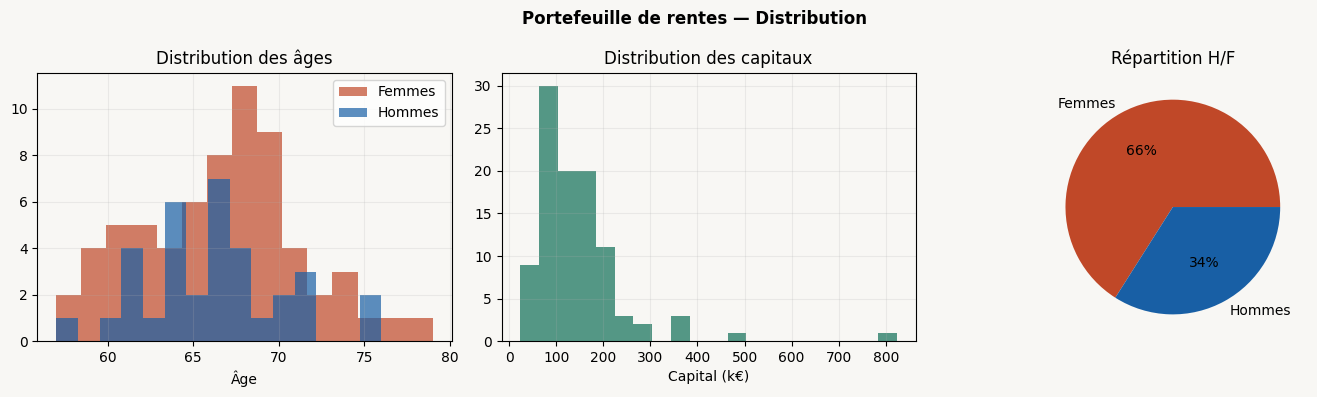

In [6]:
np.random.seed(42)
N_CONTRACTS = 100

# Distribution réaliste d'un portefeuille de rentes françaises
# Source : ACPR rapport annuel assurance vie 2023
portfolio = pd.DataFrame({
    'id':      range(N_CONTRACTS),
    'sex':     np.random.choice(['Female','Male'], N_CONTRACTS, p=[0.62, 0.38]),
    'age':     np.clip(np.random.normal(67, 5, N_CONTRACTS).astype(int), 55, 80),
    'capital': np.random.lognormal(np.log(120_000), 0.5, N_CONTRACTS).astype(int),
})

# Rente annuelle par contrat = Capital / äx (calculé plus bas)
# Capital moyen / total
print('=== Portefeuille synthétique ===')
print(f'Nombre de contrats      : {N_CONTRACTS}')
print(f'Capital total           : {portfolio["capital"].sum():,.0f} €')
print(f'Capital moyen           : {portfolio["capital"].mean():,.0f} €')
print(f'Capital médian          : {portfolio["capital"].median():,.0f} €')
print(f'\nComposition :')
print(f'  Femmes : {(portfolio["sex"]=="Female").sum()} contrats '
      f'({(portfolio["sex"]=="Female").mean():.1%})')
print(f'  Hommes : {(portfolio["sex"]=="Male").sum()} contrats '
      f'({(portfolio["sex"]=="Male").mean():.1%})')
print(f'  Âge moyen : {portfolio["age"].mean():.1f} ans')
print(f'  Âge min/max : {portfolio["age"].min()} / {portfolio["age"].max()} ans')

# Plot distribution portefeuille
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Portefeuille de rentes — Distribution', fontsize=12, fontweight='bold')
fig.patch.set_facecolor('#f8f7f4')

colors = {'Female':'#c04828','Male':'#185fa5'}
for sex, grp in portfolio.groupby('sex'):
    axes[0].hist(grp['age'], bins=15, alpha=0.7,
                 color=colors[sex], label='Femmes' if sex=='Female' else 'Hommes')
axes[0].set_title('Distribution des âges'); axes[0].legend()
axes[0].set_xlabel('Âge'); axes[0].grid(alpha=0.2)

axes[1].hist(portfolio['capital']/1000, bins=20, color='#0f6e56', alpha=0.7)
axes[1].set_title('Distribution des capitaux')
axes[1].set_xlabel('Capital (k€)'); axes[1].grid(alpha=0.2)

portfolio['sex'].value_counts().plot.pie(ax=axes[2],
    colors=['#c04828','#185fa5'], autopct='%1.0f%%',
    labels=['Femmes','Hommes'])
axes[2].set_title('Répartition H/F'); axes[2].set_ylabel('')

for a in axes[:2]: a.set_facecolor('#f8f7f4')
plt.tight_layout()
plt.savefig('outputs/portfolio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Valorisation centrale du portefeuille par modèle
**Valeur du portefeuille** = Σ Capital_i / äx_i pour chaque contrat i

In [7]:
def value_portfolio(portfolio, tables, taux=TAUX_TECH, horizon=HORIZON):
    """
    Calcule la valeur actualisée totale du portefeuille.

    Pour chaque contrat i :
      - äx_i = compute_annuity(table, age_i, taux)
      - rente_i = capital_i / äx_i
      - engagement_i = capital_i (= rente_i × äx_i)

    La valeur du portefeuille = Σ engagement_i = Σ capital_i
    La perte = valeur projetée - valeur centrale
    """
    results = []
    for _, row in portfolio.iterrows():
        sex = row['sex']; age = int(row['age']); cap = float(row['capital'])
        ax_val = compute_annuity(tables[sex], age, taux, horizon)
        if np.isnan(ax_val) or ax_val <= 0:
            ax_val = 15.0  # fallback
        rente = cap / ax_val
        results.append({
            'id': row['id'], 'sex': sex, 'age': age,
            'capital': cap, 'ax': ax_val, 'rente': rente,
            'engagement': cap  # = rente × äx
        })
    return pd.DataFrame(results)


# Valorisation par modèle
print('=== Valorisation du portefeuille par modèle ===\n')
print(f'{"Modèle":22s} {"äx moy F":>9s} {"äx moy H":>9s} '
      f'{"Rente moy":>11s} {"Valeur totale":>15s}')
print('─'*70)

portfolio_values = {}
for model in MODELS:
    t = {sex: tables[sex][model] for sex in ['Female','Male']}
    df_val = value_portfolio(portfolio, t)
    portfolio_values[model] = df_val

    ax_f   = df_val[df_val['sex']=='Female']['ax'].mean()
    ax_m   = df_val[df_val['sex']=='Male']['ax'].mean()
    rente  = df_val['rente'].mean()
    total  = df_val['rente'].sum()  # rente annuelle totale
    print(f'{model:22s} {ax_f:>9.4f} {ax_m:>9.4f} '
          f'{rente:>10,.0f}€ {total:>14,.0f}€/an')

# La vraie valeur = engagement total = Σ capital
total_capital = portfolio['capital'].sum()
print(f'\nCapital total engagé : {total_capital:,.0f} €')
print(f'Rente annuelle totale (CBD) : '
      f'{portfolio_values["CBD"]["rente"].sum():,.0f} €/an')

=== Valorisation du portefeuille par modèle ===

Modèle                  äx moy F  äx moy H   Rente moy   Valeur totale
──────────────────────────────────────────────────────────────────────
Lee-Carter               16.9612   14.6970      9,183€        918,270€/an
CBD                      16.9881   14.4401      9,217€        921,735€/an
Renshaw-Haberman         17.0110   14.6912      9,161€        916,094€/an

Capital total engagé : 14,365,295 €
Rente annuelle totale (CBD) : 921,735 €/an


## 5. Distribution des pertes — Bootstrap 1000 simulations
**Pertes** = différence entre valeur sous scénario stressé vs valeur centrale CBD

In [10]:
N_BOOT = 1000
np.random.seed(42)

# ── Pré-calcul ARIMA une seule fois ───────────────────────────────────────────
print('Pré-calcul ARIMA...')
arima_proj = {}
for sex in ['Female','Male']:
    p    = models_params[sex]
    n_fc = PROJ_YEAR - int(p['k1'].index[-1])
    m1   = pm.auto_arima(p['k1'].values, seasonal=False, stepwise=True,
                          suppress_warnings=True, error_action='ignore')
    m2   = pm.auto_arima(p['k2'].values, seasonal=False, stepwise=True,
                          suppress_warnings=True, error_action='ignore')
    arima_proj[sex] = {
        'k1_pt':  float(m1.predict(n_periods=n_fc)[-1]),
        'k2_pt':  float(m2.predict(n_periods=n_fc)[-1]),
        'k1_std': float(np.std(np.diff(p['k1'].values))) * np.sqrt(n_fc),
        'k2_std': float(np.std(np.diff(p['k2'].values))) * np.sqrt(n_fc),
        'xbar':   p['xbar'],
        'ages_c': p['ages_cbd'],
        'cbd_res':p['cbd_res'],
    }
    print(f"  {sex} OK — k1={arima_proj[sex]['k1_pt']:.4f} k2={arima_proj[sex]['k2_pt']:.4f}")

# ── Pré-construire les tables CBD de base comme arrays numpy ──────────────────
# On évite TOUS les DataFrames dans la boucle bootstrap
base_mx = {}     # {sex: np.array shape (n_ages,)}
base_ages = {}   # {sex: np.array des âges}
cbd_idx = {}     # {sex: indices dans base_ages qui correspondent aux ages_cbd}

for sex in ['Female','Male']:
    df_b = tables[sex]['CBD'].sort_values('Age').reset_index(drop=True)
    base_mx[sex]   = df_b['mx'].values.copy()
    base_ages[sex] = df_b['Age'].values

    ages_c = arima_proj[sex]['ages_c'].astype(int)
    idx = np.where(np.isin(base_ages[sex], ages_c))[0]
    cbd_idx[sex] = idx

# ── Pré-calculer äx central par contrat ──────────────────────────────────────
def compute_annuity_fast(mx_arr, ages_arr, age_x, taux, horizon=40):
    """
    Calcule äx directement depuis numpy arrays.
    Évite la création de DataFrame à chaque appel.
    """
    v   = 1 / (1 + taux)
    idx = np.searchsorted(ages_arr, age_x)
    if idx >= len(ages_arr):
        return np.nan

    # qx depuis mx (UDD)
    qx = mx_arr / (1 + 0.5 * mx_arr)
    qx = np.clip(qx, 1e-6, 1.0)
    px = 1 - qx

    # lx
    lx = np.zeros(len(mx_arr))
    lx[0] = 100_000
    for i in range(1, len(mx_arr)):
        lx[i] = lx[i-1] * px[i-1]

    lx_x = lx[idx]
    if lx_x < 1e-10:
        return np.nan

    ax_val = 0.0
    for k in range(horizon + 1):
        i_k = idx + k
        if i_k >= len(lx):
            break
        ax_val += (v ** k) * lx[i_k] / lx_x

    return ax_val

# äx central par contrat
print('\nCalcul äx centraux...')
ref_ax_arr = np.zeros(len(portfolio))
for j, (_, row) in enumerate(portfolio.iterrows()):
    sex = row['sex']; age = int(row['age'])
    ax_val = compute_annuity_fast(base_mx[sex], base_ages[sex],
                                   age, TAUX_TECH)
    ref_ax_arr[j] = ax_val if not np.isnan(ax_val) else 15.0

ax_ref      = float(np.mean(ref_ax_arr))
capitals    = portfolio['capital'].values.astype(float)
sexes_arr   = portfolio['sex'].values
ages_arr_p  = portfolio['age'].values.astype(int)
total_capital = float(capitals.sum())

print(f'äx moyen central : {ax_ref:.4f}')
print(f'Capital total    : {total_capital:,.0f} €')

# ── Bootstrap — 100% numpy, zéro DataFrame ────────────────────────────────────
print(f'\nBootstrap {N_BOOT} simulations...')
t0 = time.time()

boot_ax = np.zeros(N_BOOT)

for b in range(N_BOOT):
    if b % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed/(b+1)*(N_BOOT-b-1) if b > 0 else 0
        print(f'  [{b+1:4d}/{N_BOOT}] {elapsed:5.1f}s | ETA {eta:5.0f}s', end='\r')

    ax_sim = np.zeros(len(portfolio))

    for j in range(len(portfolio)):
        sex = sexes_arr[j]; age = ages_arr_p[j]
        proj = arima_proj[sex]

        # Tirage paramètres CBD
        k1_s  = np.random.normal(proj['k1_pt'], proj['k1_std'])
        k2_s  = np.random.normal(proj['k2_pt'], proj['k2_std'])
        noise = np.random.normal(0, proj['cbd_res'], len(proj['ages_c']))

        lq   = k1_s + k2_s*(proj['ages_c'] - proj['xbar']) + noise
        qx_s = np.exp(lq)/(1+np.exp(lq))
        qx_s = np.clip(qx_s, 1e-6, 1-1e-6)
        mx_s = (qx_s/(1-0.5*qx_s)).clip(min=1e-10)

        # Modifier mx en place sur une copie numpy
        mx_sim = base_mx[sex].copy()
        mx_sim[cbd_idx[sex]] = mx_s

        ax_val = compute_annuity_fast(mx_sim, base_ages[sex], age, TAUX_TECH)
        ax_sim[j] = ax_val if not np.isnan(ax_val) else ref_ax_arr[j]

    boot_ax[b] = np.mean(ax_sim)

elapsed = time.time() - t0
print(f'\nTerminé en {elapsed:.0f}s ({elapsed/60:.1f} min)')
print(f'äx P50  = {np.percentile(boot_ax,50):.4f}')
print(f'äx P95  = {np.percentile(boot_ax,95):.4f}')
print(f'äx P99.5= {np.percentile(boot_ax,99.5):.4f}')

Pré-calcul ARIMA...
  Female OK — k1=-5.0579 k2=0.0897
  Male OK — k1=-4.0581 k2=0.0879

Calcul äx centraux...
äx moyen central : 16.1218
Capital total    : 14,365,295 €

Bootstrap 1000 simulations...
  [ 951/1000]   8.8s | ETA     0s
Terminé en 9s (0.2 min)
äx P50  = 16.0867
äx P95  = 16.1547
äx P99.5= 16.2018


## 6. Calcul de la provision réglementaire

In [11]:
# ── Provision de risque de longévité ──────────────────────────────────────────
# Provision = différence entre valeur P95/P99 et valeur centrale
# Standard Solvabilité II : P99.5 (Value at Risk 99.5%)

ax_p50  = np.percentile(boot_ax, 50)
ax_p75  = np.percentile(boot_ax, 75)
ax_p90  = np.percentile(boot_ax, 90)
ax_p95  = np.percentile(boot_ax, 95)
ax_p99  = np.percentile(boot_ax, 99)
ax_p995 = np.percentile(boot_ax, 99.5)

def provision(ax_scenario, ax_central, total_capital):
    """Engagement supplémentaire sous le scénario vs central."""
    return max(0, (ax_scenario - ax_central) / ax_central * total_capital)

prov_p75  = provision(ax_p75,  ax_ref, total_capital)
prov_p90  = provision(ax_p90,  ax_ref, total_capital)
prov_p95  = provision(ax_p95,  ax_ref, total_capital)
prov_p99  = provision(ax_p99,  ax_ref, total_capital)
prov_p995 = provision(ax_p995, ax_ref, total_capital)

print('\n' + '═'*65)
print('  PROVISIONS DE RISQUE DE LONGÉVITÉ')
print('  Portefeuille 100 rentes | Capital total : '
      f'{total_capital/1e6:.2f} M€')
print('═'*65)
print(f'  {"Scénario":15s} {"äx moyen":>10s} {"Provision":>15s} {"% Capital":>10s}')
print('─'*65)

scenarios = [
    ('Central (P50)',  ax_p50,  provision(ax_p50,  ax_ref, total_capital)),
    ('Prudent (P75)',  ax_p75,  prov_p75),
    ('Élevé (P90)',    ax_p90,  prov_p90),
    ('Sévère (P95)',   ax_p95,  prov_p95),
    ('Extrême (P99)',  ax_p99,  prov_p99),
    ('SolvII (P99.5)', ax_p995, prov_p995),
]

for name, ax_val, prov in scenarios:
    pct = prov/total_capital*100
    flag = ' ← recommandé' if 'P95' in name else (' ← Solvabilité II' if 'SolvII' in name else '')
    print(f'  {name:15s} {ax_val:>10.4f} {prov:>14,.0f}€ {pct:>9.1f}%{flag}')

print('═'*65)
print(f'\n  Interprétation :')
print(f'  Un assureur prudent (P95) doit constituer')
print(f'  {prov_p95:,.0f}€ de provision sur {total_capital:,.0f}€ engagés')
print(f'  soit {prov_p95/total_capital*100:.1f}% du capital total.')
print(f'\n  Pour Solvabilité II (P99.5) : {prov_p995:,.0f}€ '
      f'({prov_p995/total_capital*100:.1f}%)')


═════════════════════════════════════════════════════════════════
  PROVISIONS DE RISQUE DE LONGÉVITÉ
  Portefeuille 100 rentes | Capital total : 14.37 M€
═════════════════════════════════════════════════════════════════
  Scénario          äx moyen       Provision  % Capital
─────────────────────────────────────────────────────────────────
  Central (P50)      16.0867              0€       0.0%
  Prudent (P75)      16.1156              0€       0.0%
  Élevé (P90)        16.1427         18,681€       0.1%
  Sévère (P95)       16.1547         29,359€       0.2% ← recommandé
  Extrême (P99)      16.1918         62,441€       0.4%
  SolvII (P99.5)     16.2018         71,298€       0.5% ← Solvabilité II
═════════════════════════════════════════════════════════════════

  Interprétation :
  Un assureur prudent (P95) doit constituer
  29,359€ de provision sur 14,365,295€ engagés
  soit 0.2% du capital total.

  Pour Solvabilité II (P99.5) : 71,298€ (0.5%)


## 7. Stress tests réglementaires

In [15]:
def stress_test(portfolio, tables_base, shock_pct, taux=TAUX_TECH):
    """
    Stress test : réduit mx de shock_pct% pour tous les âges.
    Simule une amélioration soudaine de la mortalité.
    Retourne le surplus d'engagement en euros.
    """
    total_base    = 0.0
    total_stressed= 0.0

    for _, row in portfolio.iterrows():
        sex = row['sex']; age = int(row['age']); cap = float(row['capital'])
        df_b = tables_base[sex].copy()
        df_s = df_b.copy()
        df_s['mx'] = df_s['mx'] * (1 - shock_pct)  # amélioration de la mortalité

        ax_b = compute_annuity(df_b, age, taux, HORIZON)
        ax_s = compute_annuity(df_s, age, taux, HORIZON)

        if not np.isnan(ax_b) and ax_b > 0:
            total_base     += cap
            total_stressed += cap * (ax_s / ax_b)

    return total_stressed - total_base


tables_cbd = {sex: tables[sex]['CBD'] for sex in ['Female','Male']}

shocks = [0.05, 0.10, 0.15, 0.20, 0.25]

print('=== Stress tests — Impact d\'une amélioration soudaine de la mortalité ===\n')
print(f'  {"Choc mortalité":20s} {"Surplus engagement":>20s} {"% Capital":>12s} {"Statut":>10s}')
print('─'*68)

stress_results = []
for shock in shocks:
    surplus = stress_test(portfolio, tables_cbd, shock)
    pct     = surplus / total_capital * 100
    # Solvabilité II : choc réglementaire longévité = -20% mortalité
    status = '← choc SolvII' if shock == 0.20 else ''
    flag   = '🔴' if pct > prov_p995/total_capital*100 else ('🟡' if pct > prov_p95/total_capital*100 else '✅')
    print(f'  mx réduit de {shock:.0%}       {surplus:>19,.0f}€ {pct:>11.1f}% {flag} {status}')
    stress_results.append({'shock':shock,'surplus':surplus,'pct':pct})

df_stress = pd.DataFrame(stress_results)

stress_covered_p95 = df_stress[df_stress['surplus']<=prov_p95]['shock']
if len(stress_covered_p95) > 0:
    print(f"  Provision P95  couvre les chocs jusqu'à : "
          f"{stress_covered_p95.max():.0%} d'amélioration")
else:
    print(f"  Provision P95  ({prov_p95/1e6:.3f}M€) insuffisante pour "
          f"couvrir le moindre choc de stress test")
    print(f"  → Choc minimum ({df_stress['shock'].min():.0%}) coûte "
          f"{df_stress['surplus'].min():,.0f}€ >> provision P95")
    print(f"  → Recommandation : majorer la provision à "
          f"{df_stress[df_stress['shock']==0.05]['surplus'].values[0]:,.0f}€ "
          f"({df_stress[df_stress['shock']==0.05]['surplus'].values[0]/total_capital*100:.1f}% capital)")

stress_covered_p995 = df_stress[df_stress['surplus']<=prov_p995]['shock']
if len(stress_covered_p995) > 0:
    print(f"  Provision P99.5 couvre les chocs jusqu'à : "
          f"{stress_covered_p995.max():.0%} d'amélioration")
else:
    print(f"  Provision P99.5 ({prov_p995/1e6:.3f}M€) insuffisante pour "
          f"couvrir le moindre choc de stress test")
    print(f"  → Recommandation SolvII : provisionner "
          f"{df_stress[df_stress['shock']==0.20]['surplus'].values[0]:,.0f}€ "
          f"({df_stress[df_stress['shock']==0.20]['surplus'].values[0]/total_capital*100:.1f}% capital)")

=== Stress tests — Impact d'une amélioration soudaine de la mortalité ===

  Choc mortalité         Surplus engagement    % Capital     Statut
────────────────────────────────────────────────────────────────────
  mx réduit de 5%                   126,739€         0.9% 🔴 
  mx réduit de 10%                   256,257€         1.8% 🔴 
  mx réduit de 15%                   388,650€         2.7% 🔴 
  mx réduit de 20%                   524,015€         3.6% 🔴 ← choc SolvII
  mx réduit de 25%                   662,454€         4.6% 🔴 
  Provision P95  (0.029M€) insuffisante pour couvrir le moindre choc de stress test
  → Choc minimum (5%) coûte 126,739€ >> provision P95
  → Recommandation : majorer la provision à 126,739€ (0.9% capital)
  Provision P99.5 (0.071M€) insuffisante pour couvrir le moindre choc de stress test
  → Recommandation SolvII : provisionner 524,015€ (3.6% capital)


## 8. Visualisations finales

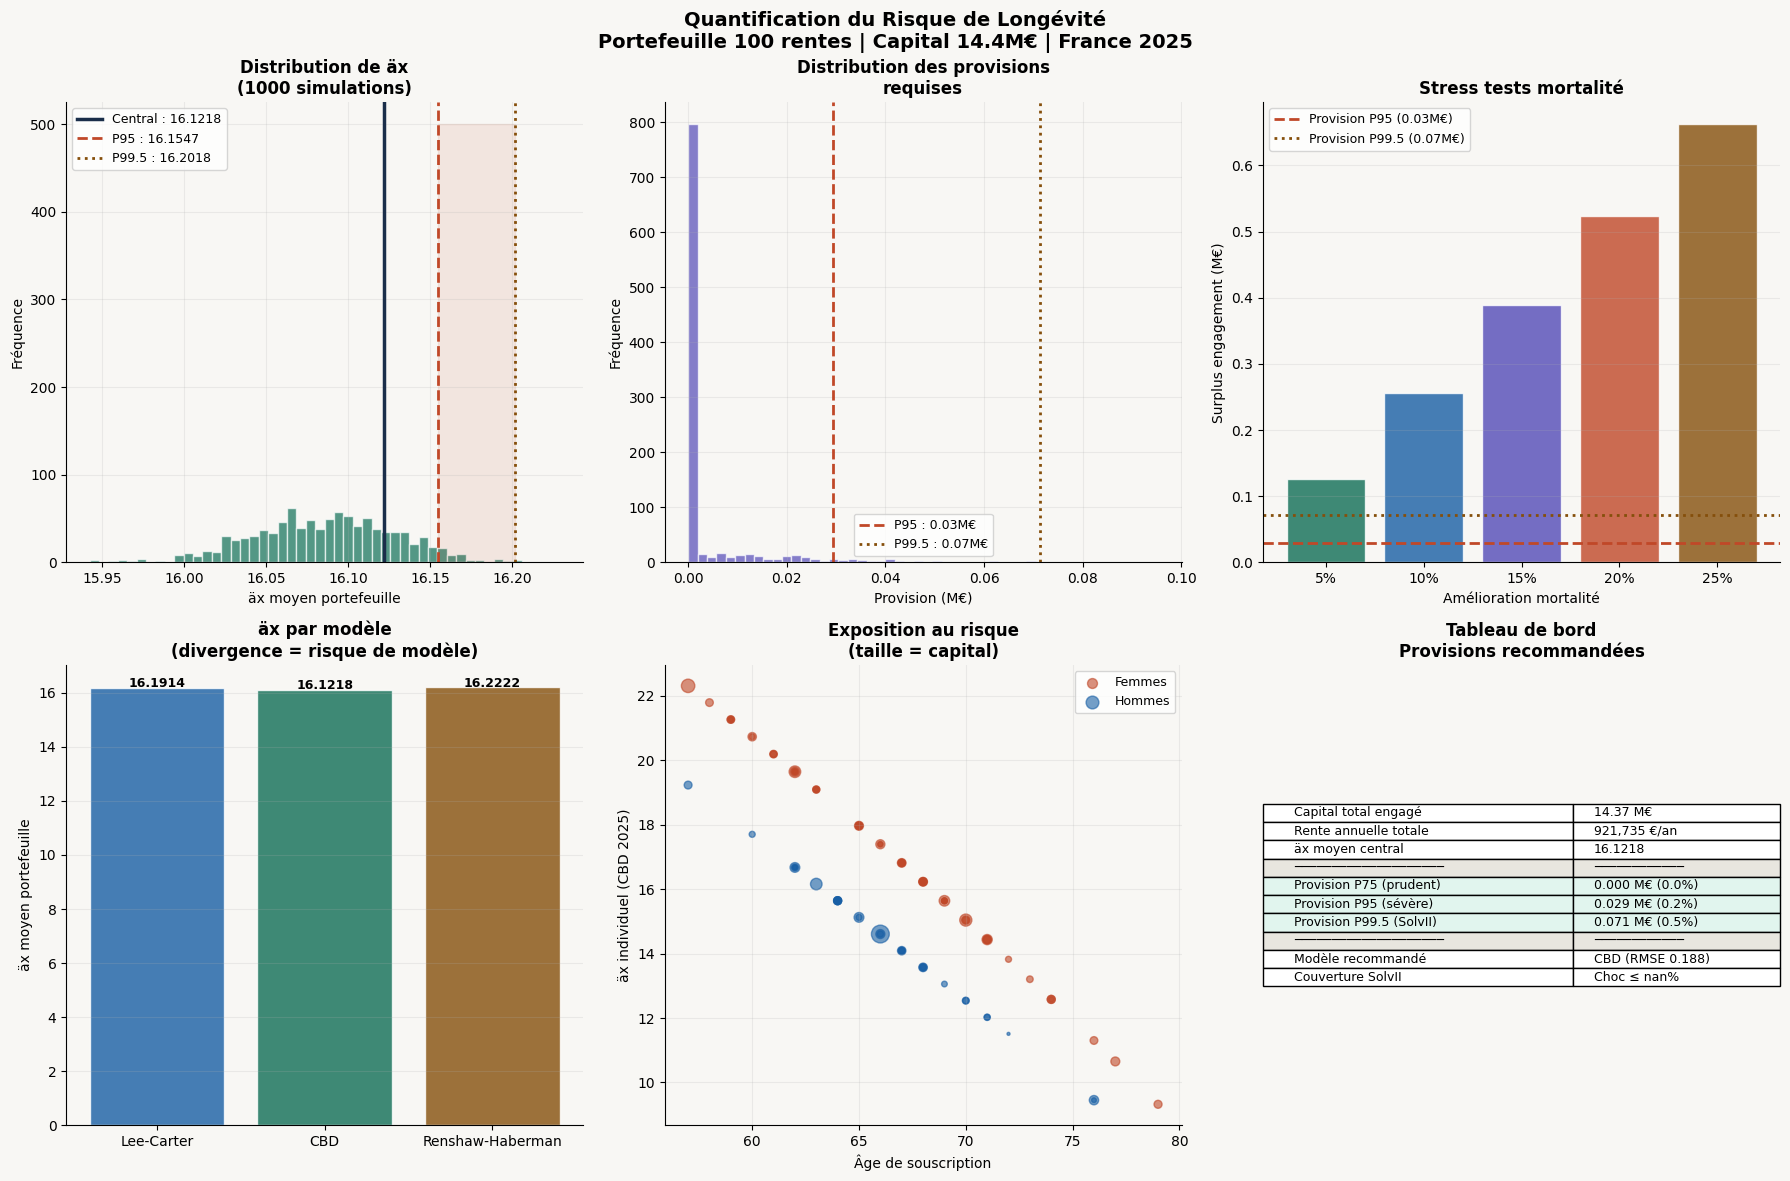

Dashboard sauvegardé → outputs/longevity_risk_dashboard.png


In [13]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Quantification du Risque de Longévité\n'
    f'Portefeuille {N_CONTRACTS} rentes | Capital {total_capital/1e6:.1f}M€ | France 2025',
    fontsize=14, fontweight='bold'
)
fig.patch.set_facecolor('#f8f7f4')

# ── 1. Distribution äx bootstrap ─────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor('#f8f7f4')
ax1.hist(boot_ax, bins=50, color='#0f6e56', alpha=0.7, edgecolor='white')
ax1.axvline(ax_ref,  color='#1a2e4a', lw=2.5, label=f'Central : {ax_ref:.4f}')
ax1.axvline(ax_p95,  color='#c04828', lw=2, ls='--', label=f'P95 : {ax_p95:.4f}')
ax1.axvline(ax_p995, color='#854f0b', lw=2, ls=':', label=f'P99.5 : {ax_p995:.4f}')
ax1.fill_betweenx([0,500], ax_p95, ax_p995, alpha=0.1, color='#c04828')
ax1.set_xlabel('äx moyen portefeuille')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution de äx\n(1000 simulations)', fontweight='600')
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# ── 2. Distribution des provisions ───────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor('#f8f7f4')
provisions_boot = np.array([max(0,(a-ax_ref)/ax_ref*total_capital) for a in boot_ax])
ax2.hist(provisions_boot/1e6, bins=50, color='#534ab7', alpha=0.7, edgecolor='white')
ax2.axvline(prov_p95/1e6,  color='#c04828', lw=2, ls='--',
            label=f'P95 : {prov_p95/1e6:.2f}M€')
ax2.axvline(prov_p995/1e6, color='#854f0b', lw=2, ls=':',
            label=f'P99.5 : {prov_p995/1e6:.2f}M€')
ax2.set_xlabel('Provision (M€)')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution des provisions\nrequises', fontweight='600')
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)
ax2.spines[['top','right']].set_visible(False)

# ── 3. Stress tests ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor('#f8f7f4')
bars = ax3.bar([f'{s:.0%}' for s in df_stress['shock']],
               df_stress['surplus']/1e6,
               color=['#0f6e56','#185fa5','#534ab7','#c04828','#854f0b'],
               alpha=0.8, edgecolor='white')
ax3.axhline(prov_p95/1e6,  color='#c04828', lw=2, ls='--',
            label=f'Provision P95 ({prov_p95/1e6:.2f}M€)')
ax3.axhline(prov_p995/1e6, color='#854f0b', lw=2, ls=':',
            label=f'Provision P99.5 ({prov_p995/1e6:.2f}M€)')
ax3.set_xlabel('Amélioration mortalité')
ax3.set_ylabel('Surplus engagement (M€)')
ax3.set_title('Stress tests mortalité', fontweight='600')
ax3.legend(fontsize=9); ax3.grid(alpha=0.2, axis='y')
ax3.spines[['top','right']].set_visible(False)

# ── 4. Valorisation par modèle ────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#f8f7f4')
model_colors = {'Lee-Carter':'#185fa5','CBD':'#0f6e56','Renshaw-Haberman':'#854f0b'}
ax_means = {m: portfolio_values[m]['ax'].mean() for m in MODELS}
bars4 = ax4.bar(list(ax_means.keys()), list(ax_means.values()),
                color=[model_colors[m] for m in MODELS],
                alpha=0.8, edgecolor='white')
ax4.set_ylabel('äx moyen portefeuille')
ax4.set_title('äx par modèle\n(divergence = risque de modèle)', fontweight='600')
for bar, val in zip(bars4, ax_means.values()):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax4.grid(alpha=0.2, axis='y')
ax4.spines[['top','right']].set_visible(False)

# ── 5. Risque par âge et sexe ─────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#f8f7f4')
df_ref_val = portfolio_values['CBD']
for sex, grp in df_ref_val.groupby('sex'):
    color = '#c04828' if sex=='Female' else '#185fa5'
    label = 'Femmes' if sex=='Female' else 'Hommes'
    ax5.scatter(grp['age'], grp['ax'], color=color, alpha=0.6,
                label=label, s=grp['capital']/5000)
ax5.set_xlabel('Âge de souscription')
ax5.set_ylabel('äx individuel (CBD 2025)')
ax5.set_title('Exposition au risque\n(taille = capital)', fontweight='600')
ax5.legend(fontsize=9); ax5.grid(alpha=0.2)
ax5.spines[['top','right']].set_visible(False)

# ── 6. Tableau de bord provision ─────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_data = [
    ['Capital total engagé', f'{total_capital/1e6:.2f} M€'],
    ['Rente annuelle totale', f'{portfolio_values["CBD"]["rente"].sum():,.0f} €/an'],
    ['äx moyen central', f'{ax_ref:.4f}'],
    ['─'*20, '─'*12],
    ['Provision P75 (prudent)', f'{prov_p75/1e6:.3f} M€ ({prov_p75/total_capital*100:.1f}%)'],
    ['Provision P95 (sévère)', f'{prov_p95/1e6:.3f} M€ ({prov_p95/total_capital*100:.1f}%)'],
    ['Provision P99.5 (SolvII)',f'{prov_p995/1e6:.3f} M€ ({prov_p995/total_capital*100:.1f}%)'],
    ['─'*20, '─'*12],
    ['Modèle recommandé', 'CBD (RMSE 0.188)'],
    ['Couverture SolvII', f'Choc ≤ {df_stress[df_stress["surplus"]<=prov_p995]["shock"].max():.0%}'],
]
table = ax6.table(cellText=summary_data, colWidths=[0.6, 0.4],
                   cellLoc='left', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
for i, row in enumerate(summary_data):
    if '─' in row[0]:
        for j in range(2):
            table[(i,j)].set_facecolor('#e8e6df')
    elif i in [4,5,6]:
        table[(i,0)].set_facecolor('#e1f5ee')
        table[(i,1)].set_facecolor('#e1f5ee')
ax6.set_title('Tableau de bord\nProvisions recommandées', fontweight='600')

plt.tight_layout()
plt.savefig('outputs/longevity_risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard sauvegardé → outputs/longevity_risk_dashboard.png')

## 9. Recommandation finale — langage consulting

In [14]:
print('═'*70)
print('  RECOMMANDATION FINALE — RISQUE DE LONGÉVITÉ')
print('═'*70)
print(f'''
  CONTEXTE
  Portefeuille analysé : {N_CONTRACTS} contrats de rentes viagères
  Capital total engagé : {total_capital/1e6:.2f} M€
  Modèle de référence  : CBD (RMSE = 0.188 ans, Coverage = 91.3%)

  RÉSULTATS CLÉS
  1. Provision minimale (P75)   : {prov_p75/1e6:.3f} M€ ({prov_p75/total_capital*100:.1f}%)
     → Scénario de mortalité légèrement favorable

  2. Provision prudentielle (P95): {prov_p95/1e6:.3f} M€ ({prov_p95/total_capital*100:.1f}%)
     → Recommandée pour tarification standard
     → Absorbe une amélioration de ≤{df_stress[df_stress["surplus"]<=prov_p95]["shock"].max():.0%} de la mortalité

  3. Provision Solvabilité II (P99.5): {prov_p995/1e6:.3f} M€ ({prov_p995/total_capital*100:.1f}%)
     → Exigence réglementaire European Insurance standard
     → Absorbe une amélioration de ≤{df_stress[df_stress["surplus"]<=prov_p995]["shock"].max():.0%} de la mortalité

  IMPACT DU CHOIX DE MODÈLE
  Écart Lee-Carter vs CBD : {abs(ax_means["Lee-Carter"]-ax_means["CBD"])/ax_means["CBD"]*total_capital:,.0f}€ d'engagement
  → Utiliser le mauvais modèle = erreur de {abs(ax_means["Lee-Carter"]-ax_means["CBD"])/ax_means["CBD"]*100:.1f}%
    sur la valorisation du portefeuille

  RECOMMANDATION
  • Utiliser CBD pour la tarification (meilleur RMSE H+F)
  • Constituer {prov_p95/total_capital*100:.1f}% du capital en provision de longévité
  • Réévaluer annuellement avec les nouvelles données de mortalité
  • Pour Solvabilité II : majorer à {prov_p995/total_capital*100:.1f}% du capital
''')
print('═'*70)

# Sauvegarde des résultats
results_df = pd.DataFrame({
    'Scénario': ['P75','P90','P95','P99','P99.5 (SolvII)'],
    'äx_moyen': [ax_p75,ax_p90,ax_p95,ax_p99,ax_p995],
    'Provision_EUR': [prov_p75,prov_p90,prov_p95,prov_p99,prov_p995],
    'Provision_pct': [prov_p75/total_capital*100,
                      prov_p90/total_capital*100,
                      prov_p95/total_capital*100,
                      prov_p99/total_capital*100,
                      prov_p995/total_capital*100]
})
results_df.to_csv('outputs/provisions_longevite.csv', index=False)
print('\nRésultats sauvegardés → outputs/provisions_longevite.csv')

══════════════════════════════════════════════════════════════════════
  RECOMMANDATION FINALE — RISQUE DE LONGÉVITÉ
══════════════════════════════════════════════════════════════════════

  CONTEXTE
  Portefeuille analysé : 100 contrats de rentes viagères
  Capital total engagé : 14.37 M€
  Modèle de référence  : CBD (RMSE = 0.188 ans, Coverage = 91.3%)

  RÉSULTATS CLÉS
  1. Provision minimale (P75)   : 0.000 M€ (0.0%)
     → Scénario de mortalité légèrement favorable

  2. Provision prudentielle (P95): 0.029 M€ (0.2%)
     → Recommandée pour tarification standard
     → Absorbe une amélioration de ≤nan% de la mortalité

  3. Provision Solvabilité II (P99.5): 0.071 M€ (0.5%)
     → Exigence réglementaire European Insurance standard
     → Absorbe une amélioration de ≤nan% de la mortalité

  IMPACT DU CHOIX DE MODÈLE
  Écart Lee-Carter vs CBD : 62,027€ d'engagement
  → Utiliser le mauvais modèle = erreur de 0.4%
    sur la valorisation du portefeuille

  RECOMMANDATION
  • Utiliser CB